# Proyek Analisis Data: E-commerce-public-dataset
- **Nama:** Azkia Wahtilafinnahri
- **Email:** Azkiawahtilafinnahri@gmail.com
- **ID Dicoding:** azkiajeon

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk  mana yang sering dan paling jarang dibeli customer dalam 3 bulan terakhir (Juni sampai dengan Agustus 2018)?
- **Pertanyaan 2:** Berapa rata-rata jumlah produk dalam satu pesanan setiap bulan dalam 3 bulan terakhir (Juni sampai dengan Agustus 2018)?
- **Pertanyaan 3:** Berapa rata-rata total nilai transaksi  dalam satu pesanan setiap bulan dalam 3 bulan terakhir (Juni sampai dengan Agustus 2018)? 

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
orders = pd.read_csv('orders_dataset.csv')
items = pd.read_csv('order_items_dataset.csv')
products = pd.read_csv('products_dataset.csv')
category = pd.read_csv('product_category_name_translation.csv')

In [3]:
#rename category
products = products.merge(category, on='product_category_name', how='left')
products.rename(columns={'product_category_name_english': 'category'}, inplace=True)

**Insight:** 
- Dataset berhasil dimuat karena berada dalam 1 folder yang sama 
- Dataset yang dimuat adalah orders, order_items, products, dan category translation

### Assessing Data

#### Identifying dataset orders problem

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [6]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

#### Identifying dataset items problem

In [7]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [8]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [9]:
items.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

#### Identifying dataset products problem

In [10]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,category
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [11]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
 9   category                    32328 non-null  object 
dtypes: float64(7), object(3)
memory usage: 2.5+ MB


In [12]:
products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
category                      623
dtype: int64

#### Identifying dataset category problem

In [13]:
category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [14]:
category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [15]:
category.isna().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

**Steps to Take:**
- Terdapat mising value di dalam dataset orders di kolom "order_approved_at", "order_delivered_carrier_date", dan "order_delivered_customer_date" sehingga perlu dicleaning  agar hasil analisis tidak bias. atribut 'order_approved_at' dan 'order_delivered_carrier_date' masih ada yang kosong juga akan di drop juga karena pada atribut  'order_approved_at' yang kosong bisa jadi terjadi karena order belum di upload atau ada missing logs, begitu juga ppada atribut 'order_delivered_carrier_date' bisa jadi barang belum diserahkan kepada kurir.
- Terdapat banyak missing value di dalam dataset products. karena hanya fokus pada kategori sehingga hanya data yang memiliki "product_category_name" kosong dibuat drop. atribut yang lain  juga dibuat drop karena hanya 2 saja yang kosong sehingga tidak akan mempengaruhi hasil analisis. 

**Insight:** (Opsional)
- Terdapat mising value di dataset orders di kolom "order_approved_at", "order_delivered_carrier_date", dan "order_delivered_customer_date" karena tidak semua pesanan diproses atau dikirim
- Terdapat banyak missing value di dalam dataset products dan data yang atribut "product_category_name" nya kosong akan dihapus karena tidak bisa dibuat analisis

### Cleaning Data

#### Fixing dataset orfers problem

In [16]:
#drop data selain yang delivered
orders = orders.dropna(subset=['order_delivered_customer_date',
                                'order_approved_at',
                                'order_delivered_carrier_date'])


In [17]:
orders.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [18]:
#### Fixing dataset products problem
products = products.dropna(subset=['product_category_name'])
products = products.dropna(subset=['product_weight_g'])
products = products.dropna(subset=['product_length_cm'])
products = products.dropna(subset=['product_height_cm'])
products = products.dropna(subset=['product_width_cm'])

In [19]:
products.isna().sum()

product_id                     0
product_category_name          0
product_name_lenght            0
product_description_lenght     0
product_photos_qty             0
product_weight_g               0
product_length_cm              0
product_height_cm              0
product_width_cm               0
category                      13
dtype: int64

**Insight:** (Opsional)
- Semua dataset yang akan digunakan sudah dan siap digunakan dengan cara men-drop atribut-atribut yang dinilai noisy atau tidak dapat digunakan

## Exploratory Data Analysis (EDA)

In [22]:
df = items.merge(orders, on='order_id', how='inner')
df = df.merge(products[['product_id', 'category']], on='product_id', how='left')

In [23]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df = df[
    (df['order_purchase_timestamp'] >= '2018-06-01') &
    (df['order_purchase_timestamp'] <= '2018-08-31')
]

df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

### EDA Univariate

#### descriptive statistics

In [24]:
numeric_cols = ['price', 'freight_value']

desc_stats = df[numeric_cols].describe(percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
print(desc_stats)

              price  freight_value
count  21109.000000   21109.000000
mean     121.353692      21.913499
std      192.006397      18.932315
min        2.200000       0.000000
5%        16.900000       7.470000
10%       23.990000       8.030000
25%       39.900000      13.110000
50%       75.000000      18.280000
75%      134.900000      23.290000
90%      220.700000      39.410000
95%      349.970000      53.540000
max     6729.000000     375.280000


In [25]:
for col in numeric_cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f'{col}')
    print(f'  Skewness : {skew:.4f}')
    print(f'  Kurtosis : {kurt:.4f}')
    print()

price
  Skewness : 8.7948
  Kurtosis : 149.5722

freight_value
  Skewness : 5.5791
  Kurtosis : 58.0226



#### distribusi harga barang dan biaya pengiriman 

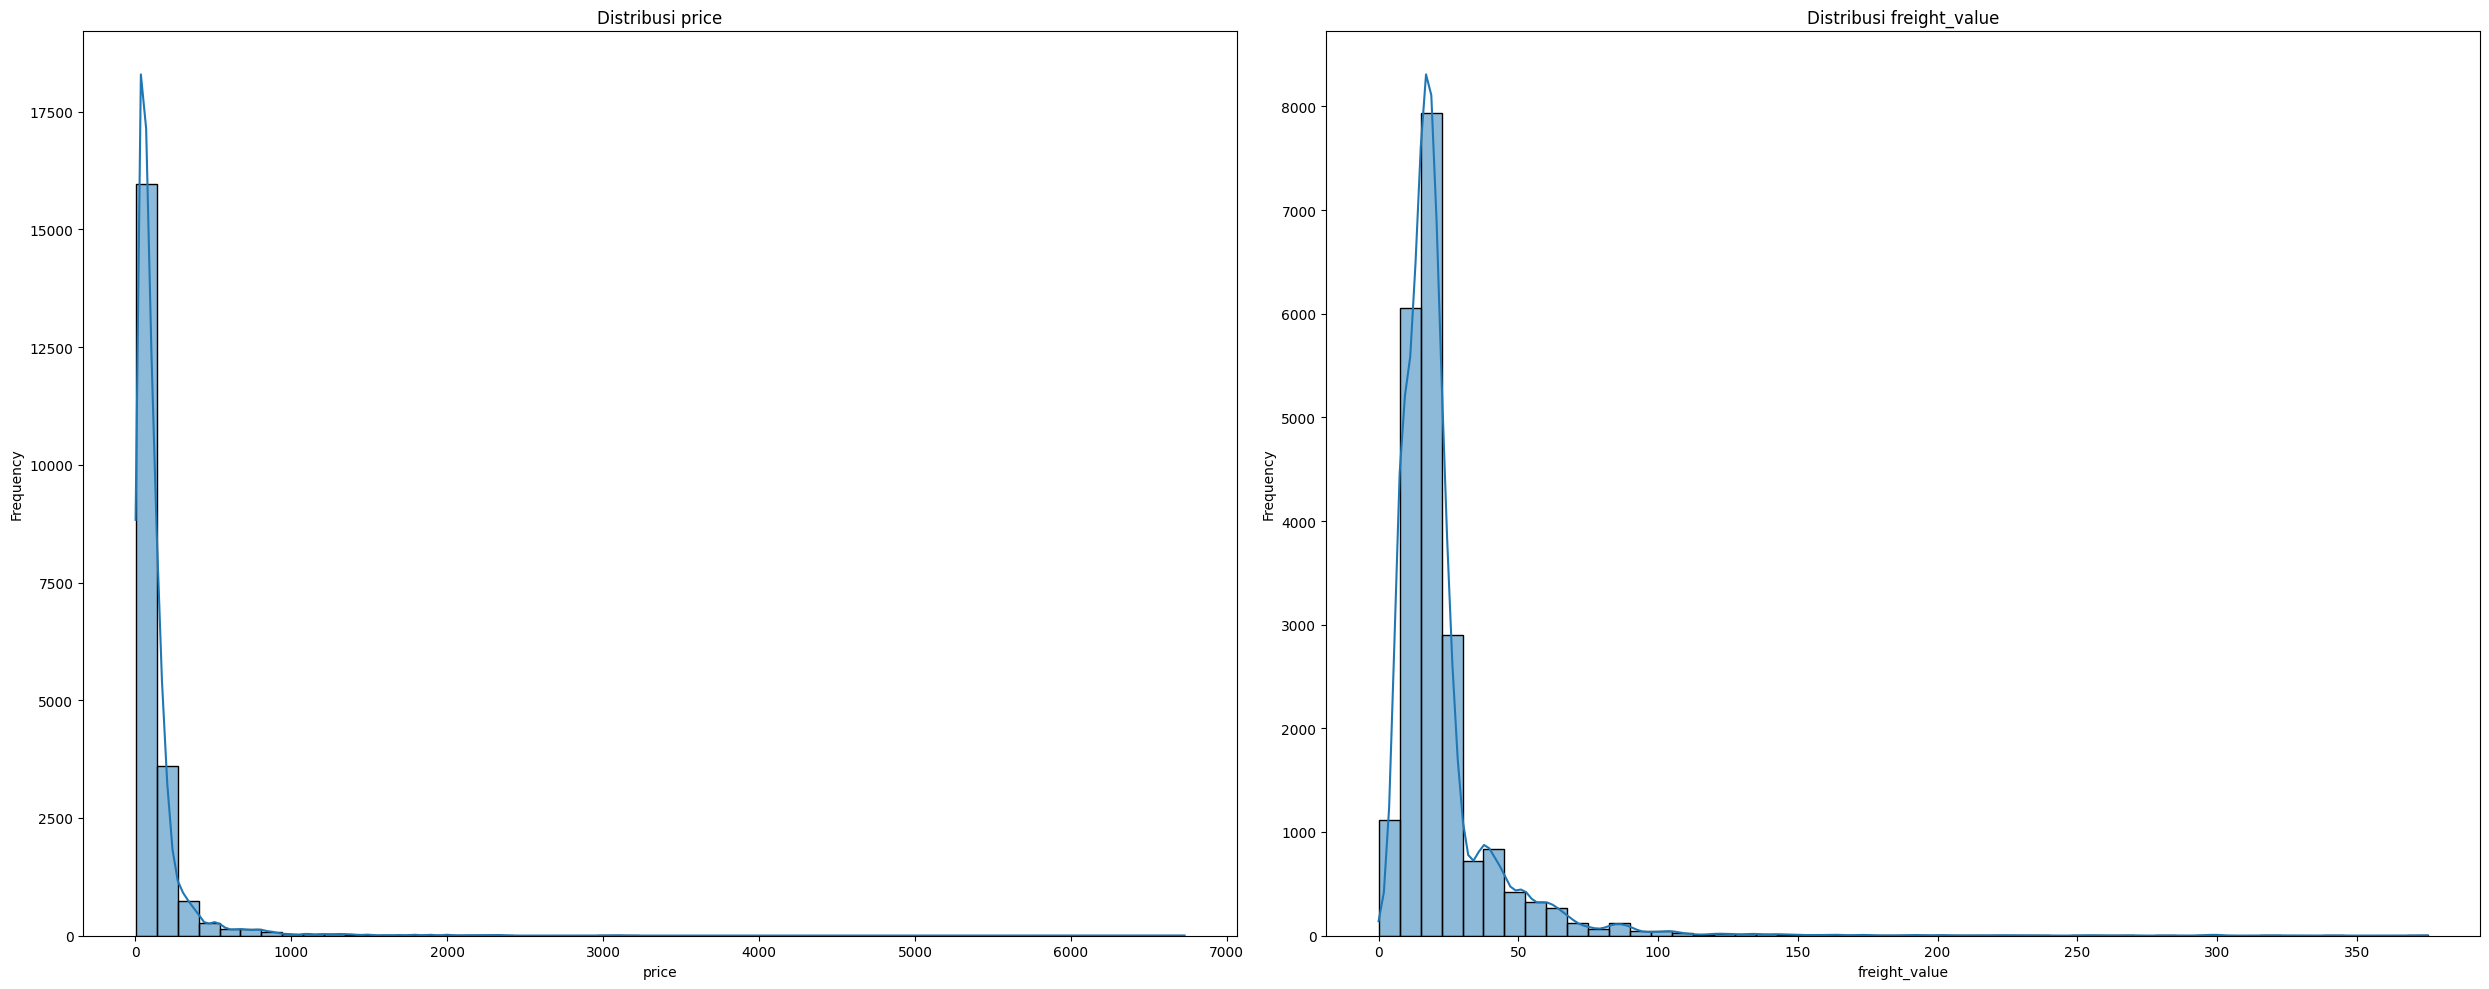

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(25, 10))

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], bins=50, kde=True, ax=ax)
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Quartiles, Median, dan Outliers

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


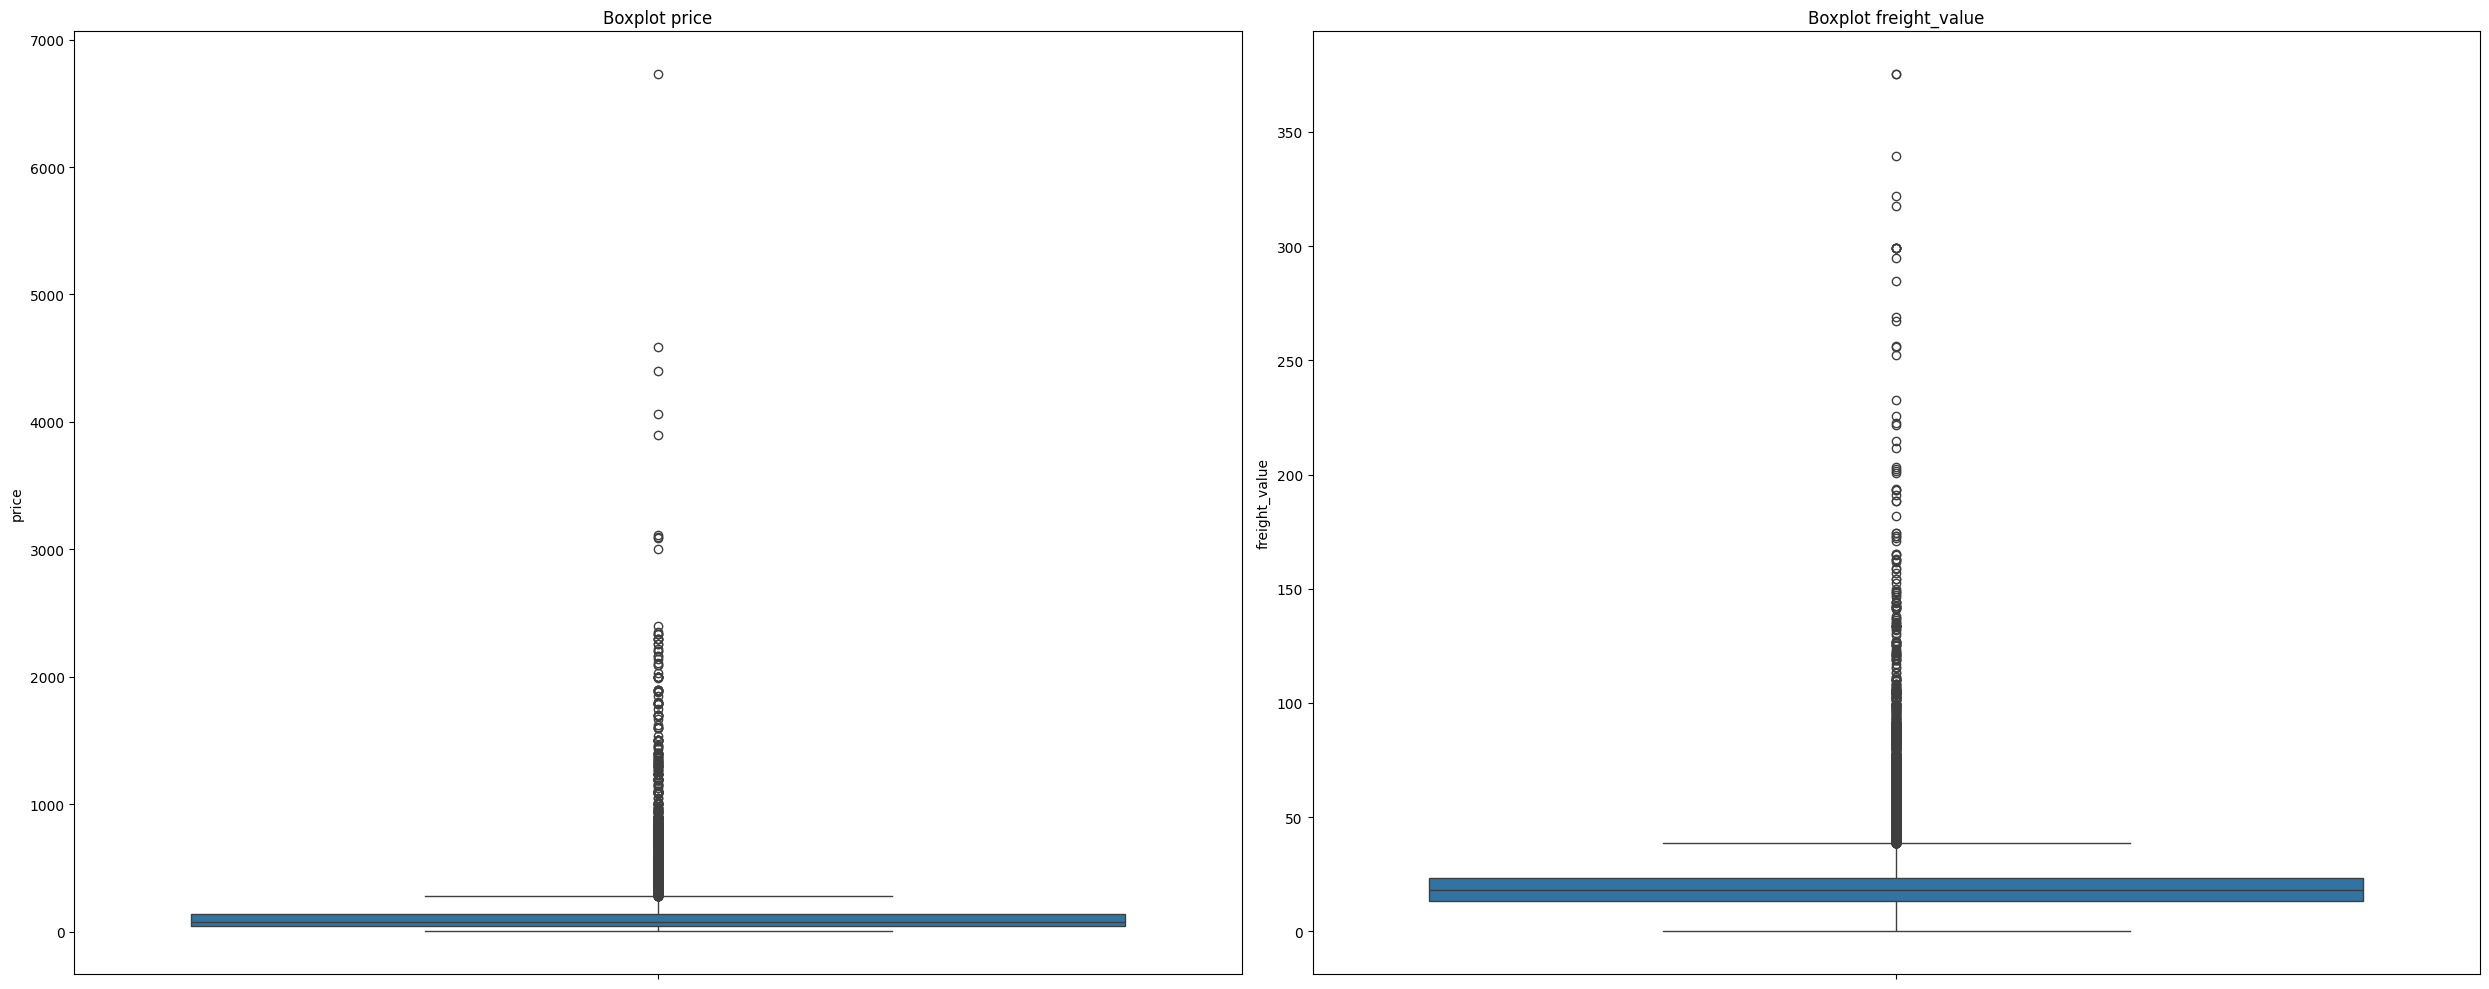

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(25, 10))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'Boxplot {col}')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

#### Mendeteksi Outlier Menggunakan Metode IQR

In [28]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'{col}')
    print(f'  Q1            : {Q1:.2f}')
    print(f'  Q3            : {Q3:.2f}')
    print(f'  IQR           : {IQR:.2f}')
    print(f'  Lower bound   : {lower_bound:.2f}')
    print(f'  Upper bound   : {upper_bound:.2f}')
    print(f'  Jumlah outlier: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')
    print()

price
  Q1            : 39.90
  Q3            : 134.90
  IQR           : 95.00
  Lower bound   : -102.60
  Upper bound   : 277.40
  Jumlah outlier: 1528 (7.24%)

freight_value
  Q1            : 13.11
  Q3            : 23.29
  IQR           : 10.18
  Lower bound   : -2.16
  Upper bound   : 38.56
  Jumlah outlier: 2242 (10.62%)



### EDA Multivariate

#### Analisis hubungan antar variabel

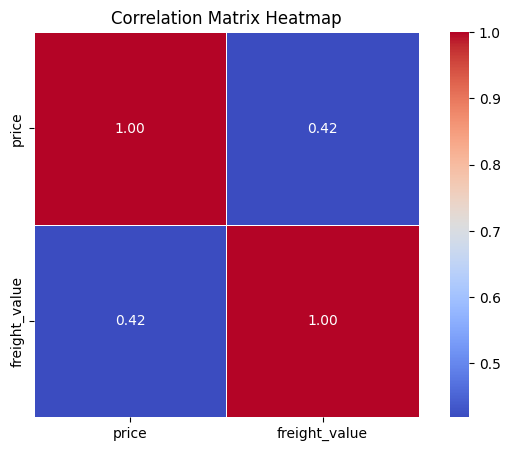

In [29]:
corr_cols = ['price', 'freight_value']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

#### Bivariate Relationship

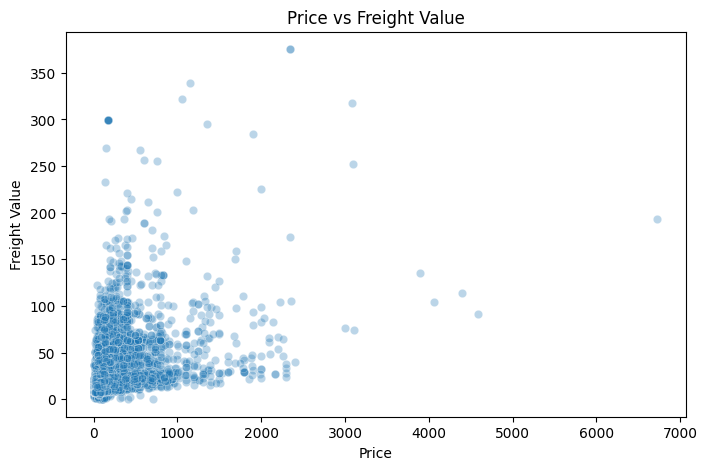

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='price', y='freight_value', alpha=0.3)
plt.title('Price vs Freight Value')
plt.xlabel('Price')
plt.ylabel('Freight Value')
plt.show()

#### pairplot

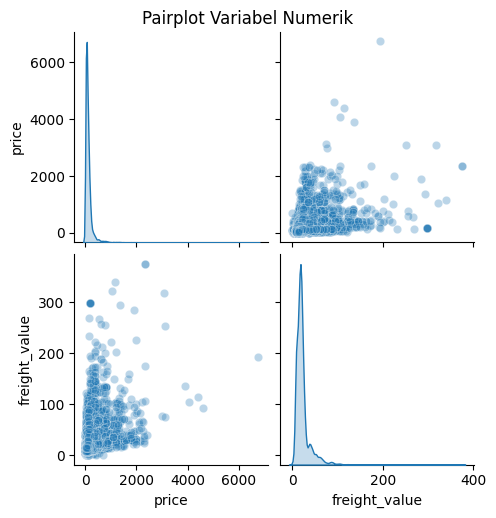

In [31]:
pairplot_df = df[['price', 'freight_value']].copy()

sns.pairplot(pairplot_df, diag_kind='kde', plot_kws={'alpha': 0.3})
plt.suptitle('Pairplot Variabel Numerik', y=1.02)
plt.show()

#### Distribusi Numerik per Kategori Produk

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


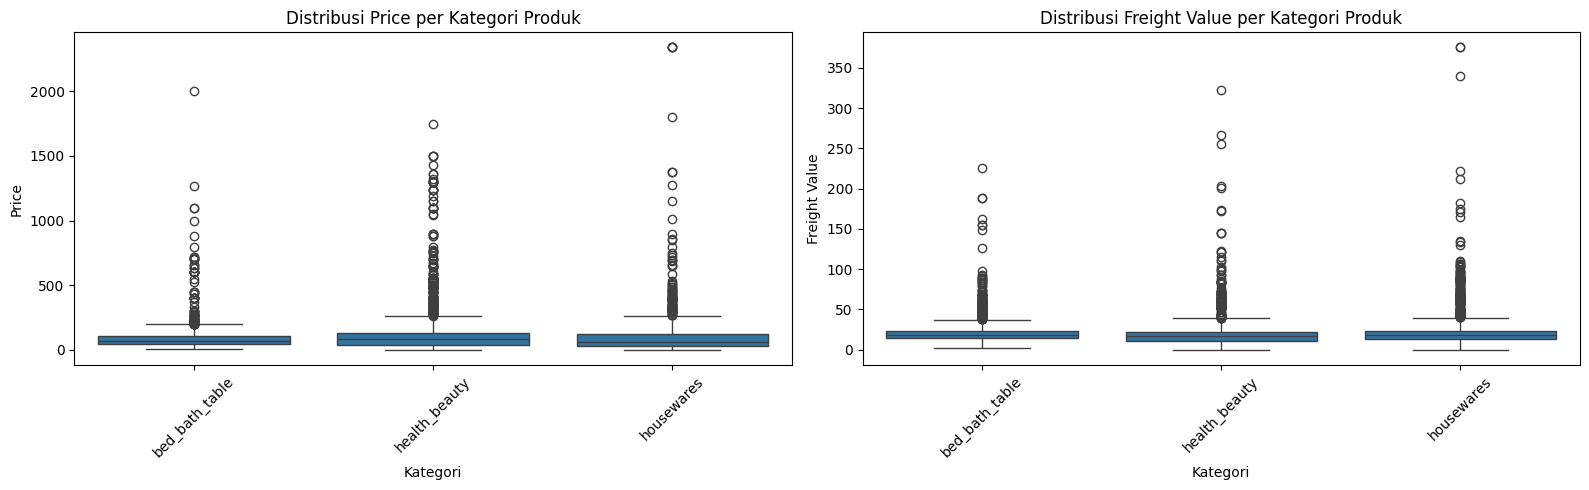

In [32]:
top_categories = df['category'].value_counts().nlargest(3).index

df_top = df[df['category'].isin(top_categories)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df_top, x='category', y='price', ax=axes[0])
axes[0].set_title('Distribusi Price per Kategori Produk')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Price')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_top, x='category', y='freight_value', ax=axes[1])
axes[1].set_title('Distribusi Freight Value per Kategori Produk')
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Freight Value')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### EDA Numerical

#### Percentile Analysis 

In [33]:
for col in numeric_cols:
    percentiles = df[col].quantile([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
    print(f'{col}')
    for p, val in percentiles.items():
        print(f'  Percentile {int(p*100):>2}th : {val:.2f}')
    print()

price
  Percentile  5th : 16.90
  Percentile 10th : 23.99
  Percentile 25th : 39.90
  Percentile 50th : 75.00
  Percentile 75th : 134.90
  Percentile 90th : 220.70
  Percentile 95th : 349.97

freight_value
  Percentile  5th : 7.47
  Percentile 10th : 8.03
  Percentile 25th : 13.11
  Percentile 50th : 18.28
  Percentile 75th : 23.29
  Percentile 90th : 39.41
  Percentile 95th : 53.54



#### Variance dan Standard Devisiasi

In [34]:
var_std = df.groupby('month')[numeric_cols].agg(['mean', 'std', 'var'])
var_std.columns = ['_'.join(col) for col in var_std.columns]
var_std.index = var_std.index.astype(str)
print(var_std)

         price_mean   price_std     price_var  freight_value_mean  \
month                                                               
2018-06  122.105319  187.488258  35151.847032           22.243041   
2018-07  124.638861  203.463545  41397.414211           22.959777   
2018-08  117.414819  184.707626  34116.907258           20.570568   

         freight_value_std  freight_value_var  
month                                          
2018-06          18.180098         330.515949  
2018-07          21.145884         447.148409  
2018-08          17.218879         296.489786  


In [35]:
monthly_avg = df.groupby('month')[numeric_cols].mean().reset_index()
monthly_avg['month'] = monthly_avg['month'].astype(str)

monthly_avg['price_growth'] = monthly_avg['price'].pct_change() * 100
monthly_avg['freight_growth'] = monthly_avg['freight_value'].pct_change() * 100

print(monthly_avg[['month', 'price', 'price_growth', 'freight_value', 'freight_growth']].to_string(index=False))

  month      price  price_growth  freight_value  freight_growth
2018-06 122.105319           NaN      22.243041             NaN
2018-07 124.638861      2.074882      22.959777        3.222293
2018-08 117.414819     -5.795978      20.570568      -10.406063


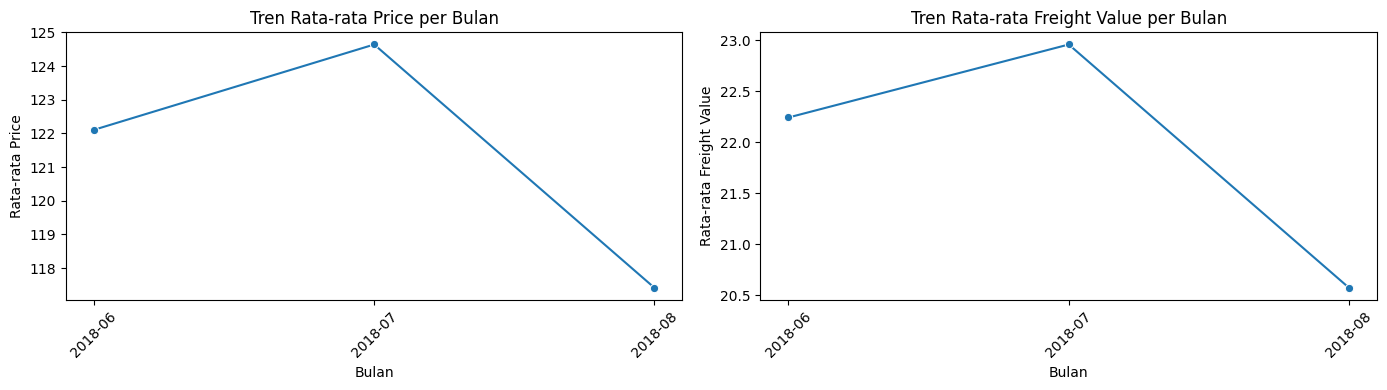

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.lineplot(data=monthly_avg, x='month', y='price', marker='o', ax=axes[0])
axes[0].set_title('Tren Rata-rata Price per Bulan')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Rata-rata Price')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=monthly_avg, x='month', y='freight_value', marker='o', ax=axes[1])
axes[1].set_title('Tren Rata-rata Freight Value per Bulan')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Rata-rata Freight Value')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Deteksi Outlier dengan metode z-score

In [37]:
for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    outliers_z = df[col].dropna()[z_scores > 3]
    print(f'{col}')
    print(f'  Jumlah outlier (Z-Score > 3) : {len(outliers_z)} ({len(outliers_z)/len(df)*100:.2f}%)')
    print()

price
  Jumlah outlier (Z-Score > 3) : 369 (1.75%)

freight_value
  Jumlah outlier (Z-Score > 3) : 375 (1.78%)



#### countplot


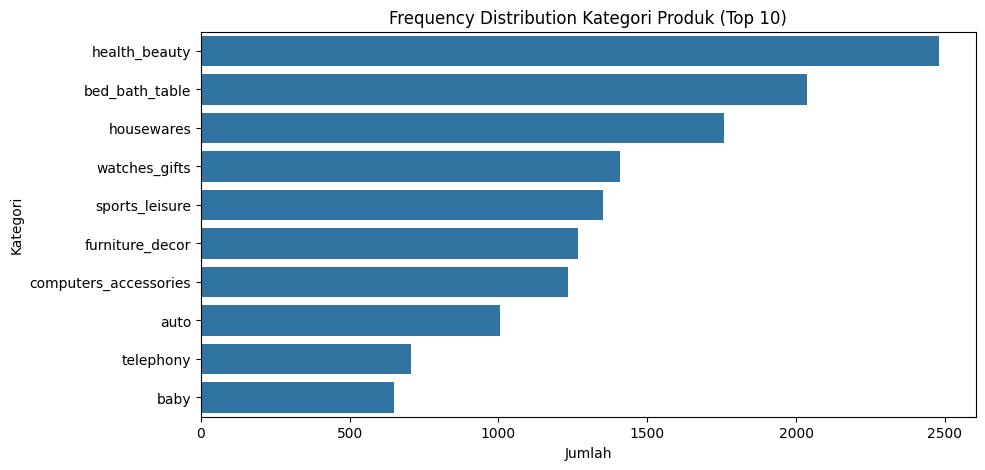

In [38]:
top_10_categories = df['category'].value_counts().nlargest(10).index
df_top10 = df[df['category'].isin(top_10_categories)]

plt.figure(figsize=(10, 5))
sns.countplot(data=df_top10, y='category', order=top_10_categories)
plt.title('Frequency Distribution Kategori Produk (Top 10)')
plt.xlabel('Jumlah')
plt.ylabel('Kategori')
plt.show()

####  Distribusi Price per Kategori Produk

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


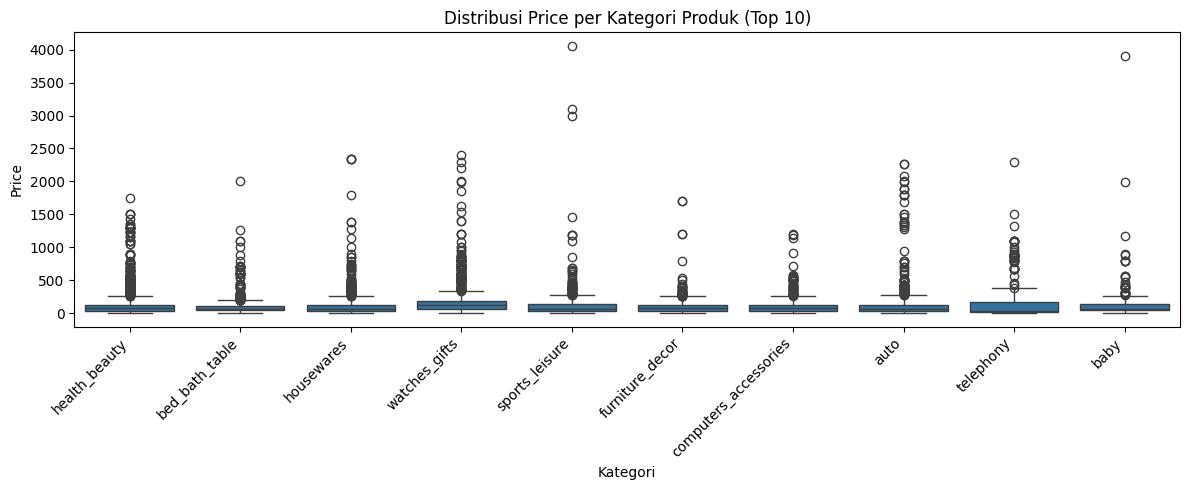

In [40]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_top10, x='category', y='price', order=top_10_categories)
plt.title('Distribusi Price per Kategori Produk (Top 10)')
plt.xlabel('Kategori')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### distribusi freight Value per Kategori Produk

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_

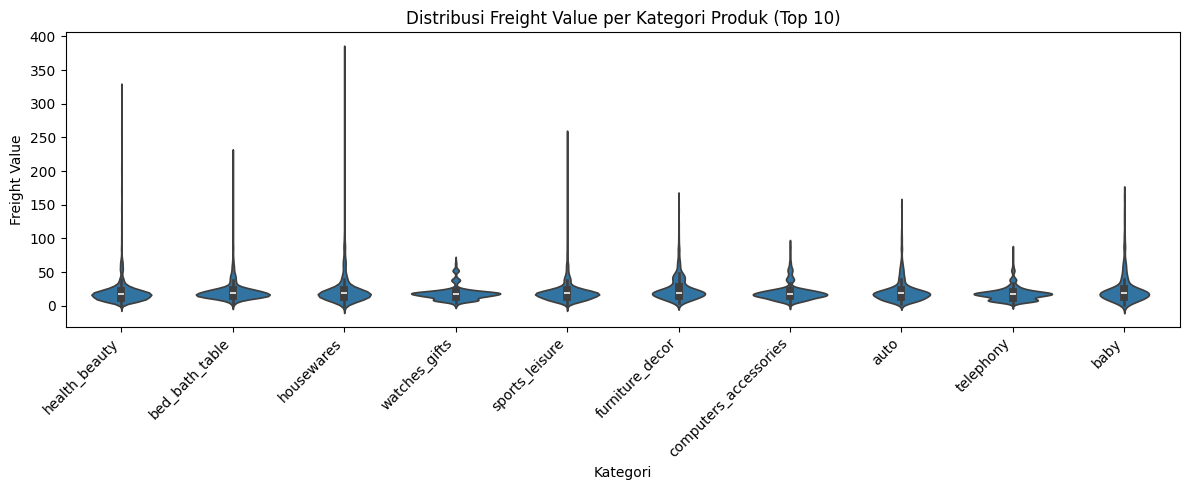

In [41]:
plt.figure(figsize=(12, 5))
sns.violinplot(data=df_top10, x='category', y='freight_value', order=top_10_categories)
plt.title('Distribusi Freight Value per Kategori Produk (Top 10)')
plt.xlabel('Kategori')
plt.ylabel('Freight Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### chi square test

In [42]:
from scipy.stats import chi2_contingency

df['price_segment'] = pd.cut(df['price'], bins=3, labels=['low', 'medium', 'high'])

contingency_table = pd.crosstab(df['category'], df['price_segment'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f'Chi-Square Statistic : {chi2:.4f}')
print(f'P-Value              : {p_value:.4f}')
print(f'Degrees of Freedom   : {dof}')
print()
if p_value < 0.05:
    print('Kesimpulan: Terdapat hubungan yang signifikan antara kategori produk dan segmen harga (p < 0.05)')
else:
    print('Kesimpulan: Tidak terdapat hubungan yang signifikan antara kategori produk dan segmen harga (p >= 0.05)')

Chi-Square Statistic : 1347.0891
P-Value              : 0.0000
Degrees of Freedom   : 134

Kesimpulan: Terdapat hubungan yang signifikan antara kategori produk dan segmen harga (p < 0.05)


#### heatmap cross tabulation

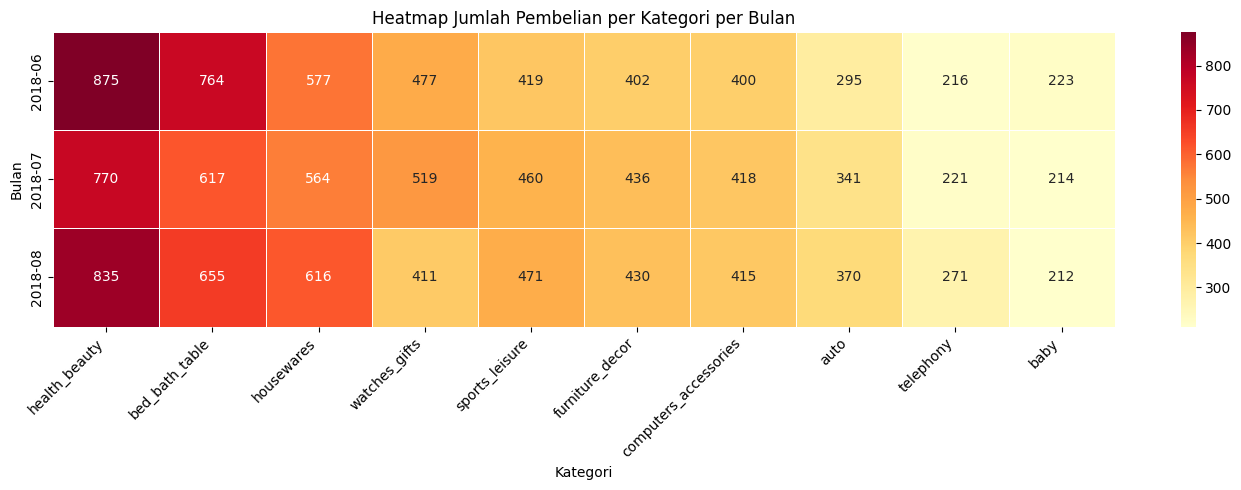

In [43]:
cross_tab = pd.crosstab(df['month'].astype(str), df['category'])
cross_tab = cross_tab[top_10_categories]

plt.figure(figsize=(14, 5))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Heatmap Jumlah Pembelian per Kategori per Bulan')
plt.xlabel('Kategori')
plt.ylabel('Bulan')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Explore Kategori produk  mana yang sering dan paling jarang dibeli customer dalam 3 bulan terakhir (Juni sampai dengan Agustus 2018)?


In [44]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,category
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [45]:
category_count = df['category'].value_counts()

In [46]:
top_3 = category_count.nlargest(3).reset_index()
top_3.columns = ['category', 'total']
print(top_3)


         category  total
0   health_beauty   2480
1  bed_bath_table   2036
2      housewares   1757


In [47]:
bottom_3 = category_count.nsmallest(3).reset_index()
bottom_3.columns = ['category', 'total']
print(bottom_3)


                            category  total
0  furniture_mattress_and_upholstery      1
1             tablets_printing_image      1
2                      fashion_sport      1


In [48]:
#simpan ke csv
top_3.to_csv('top_3_categories.csv', index=False)
bottom_3.to_csv('bottom_3_categories.csv', index=False)


**Insight:** (Opsional)
- kategori produk yang sering dibeli secara berurutan dari terbanyak adalah  'health_beauty', 'bed_bath_table', dan 'housewares'
- kategori produk yang jarang dibeli secara berurutan dari yang paling sedikit 'furniture_mattress_and_upholstery',          'tablets_printing_image', dan 'fashion_sport'

### Explore rata-rata jumlah produk dalam satu pesanan setiap bulan dalam 3 bulan terakhir (Juni sampai dengan Agustus 2018)

In [49]:
items_per_order = df.groupby(['order_id', 'month'])['product_id'].count().reset_index()
items_per_order.columns = ['order_id', 'month', 'item_count']

In [50]:
avg_items_monthly = items_per_order.groupby('month')['item_count'].mean().reset_index()
avg_items_monthly.columns = ['month', 'avg_items']

In [51]:
avg_items_monthly.to_csv('avg_items_per_month.csv', index=False)
print(avg_items_monthly)

     month  avg_items
0  2018-06   1.149442
1  2018-07   1.130604
2  2018-08   1.124547


**Insight:** (Opsional)
- rata-rata jumlah produk dalam satu pesanan pada bulan juni 2018 adalah 1.14, bulan juli 2018 adalah 1.13, dan bulan Agustus 2018 adalah 1.12 yang mana artinya customer cenderung berbelanja 1 produk saja setiap melakukan pemesanan
- Berdasarkan hasil tersebut, perusahaan dapat mempertimbangkan untuk menambahkan rekomendasi produk berupa produk yang relate atau serupa dengan produk yang sudah ditambahkan ke dalam keranjang customer

### Explore rata-rata total nilai transaksi  dalam satu pesanan setiap bulan dalam 3 bulan terakhir (Juni sampai dengan Agustus 2018)

In [52]:
order_value = df.groupby(['order_id', 'month'])['price'].sum().reset_index()
order_value.columns = ['order_id', 'month', 'total_order_value']

In [53]:
avg_monthly_value = order_value.groupby('month')['total_order_value'].mean().reset_index()
avg_monthly_value.columns = ['month', 'avg_transaction_value']

In [54]:
print(avg_monthly_value)

     month  avg_transaction_value
0  2018-06             140.353013
1  2018-07             140.917230
2  2018-08             132.038520


In [55]:
avg_monthly_value.to_csv('avg_transaction_value_per_month.csv', index=False)

**Insight:** (Opsional)
- rata-rata rata-rata total nilai transaksi  dalam satu pesanan setiap bulan beragam sehingga akan divisualisasikan datanya menjadi tren timeline

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk  mana yang sering dan paling jarang dibeli customer?

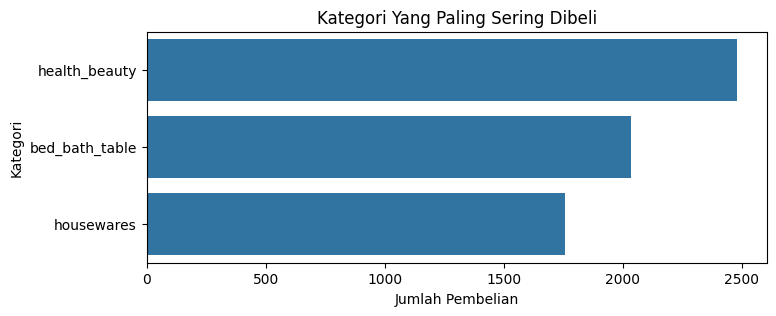

In [56]:
plt.figure(figsize=(8,3))
sns.barplot(data=top_3, x='total', y='category')
plt.title('Kategori Yang Paling Sering Dibeli')
plt.xlabel('Jumlah Pembelian')
plt.ylabel('Kategori')
plt.show()

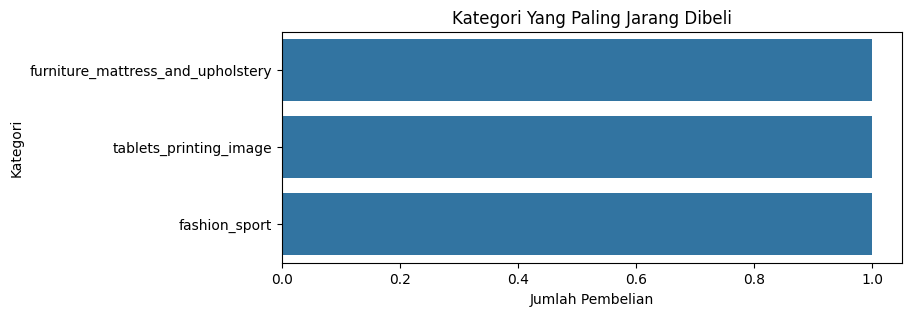

In [57]:
plt.figure(figsize=(8,3))
sns.barplot(data=bottom_3, x='total', y='category')
plt.title('Kategori Yang Paling Jarang Dibeli')
plt.xlabel('Jumlah Pembelian')
plt.ylabel('Kategori')
plt.show()

### Pertanyaan 2:Berapa rata-rata jumlah produk dalam satu pesanan?

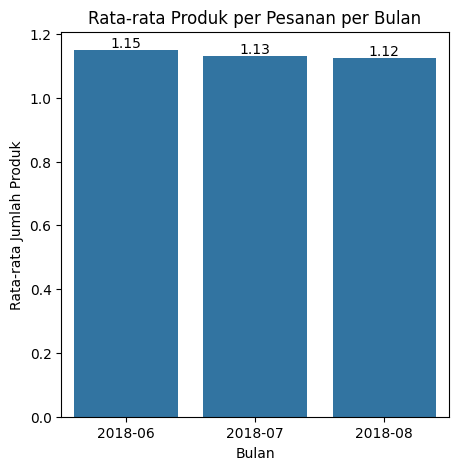

In [58]:
avg_items_monthly['month'] = avg_items_monthly['month'].astype(str)

plt.figure(figsize=(5, 5))
ax = sns.barplot(data=avg_items_monthly, x='month', y='avg_items')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')
plt.title('Rata-rata Produk per Pesanan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Jumlah Produk')
plt.show()

### Pertanyaan 3:Berapa rata-rata total nilai transaksi  dalam satu pesanan setiap bulan? 

In [59]:
avg_monthly_value['month'] = avg_monthly_value['month'].astype(str)

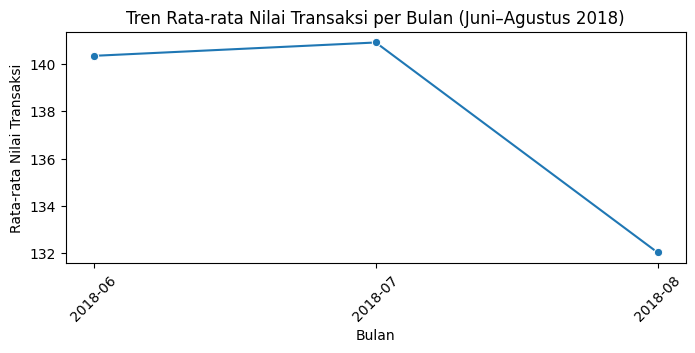

In [60]:
plt.figure(figsize=(8, 3))
sns.lineplot(data=avg_monthly_value, x='month', y='avg_transaction_value', marker='o')
plt.xticks(rotation=45)
plt.title('Tren Rata-rata Nilai Transaksi per Bulan (Juni–Agustus 2018)')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Nilai Transaksi')
plt.show()

**Insight:** (Opsional)


## Simpan main_data

In [61]:
df.to_csv('main_data.csv', index=False)

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** kategori produk yang sering dibeli dalam rentang Juli 2018 sampai dengan Agustus 2018 secara berurutan dari terbanyak adalah 'health_beauty', 'bed_bath_table', dan 'housewares'. Kategori produk yang jarang dibeli dalam rentang tahun Juli 2018 sampai dengan Agustus 2018 adalah 'furniture_mattres_and upholestorey','tablets_printing_image' dan 
'fashion_sport'

- **Conclusion pertanyaan 2:** Jumlah produk dalam satu pesanan dalam periode Juni 2018 sampai dengan Agustus 2018 adalah 1.12 sampai dengan 1.15 yang mana artinya customer cenderung berbelanja 1 produk saja setiap melakukan pemesanan. 

- **Conclusion pertanyaan 3:** Berdasarkan tren dari visualisasi di atas,  rata-rata nilai transaksi per bulan mengalami fluktuasi dari waktu ke waktu yang mungkin dipengaruhi oleh banyak faktor. Nilai tranksaksi paling besar terjadi pada bulan Juli 2018 dan paling kecil pada Agustus 2018

**Rekomendasi Action Item:**
- Produk-produk yang dikategorikan sebagai kategori populer sering ditampilkan pada halaman utama
- Menambahkan fitur rekomendasi produk di halaman produk atau keranjang yang berhubungan atau yang sering dibeli bersamaan dengan produk yang ada di keranjang
- Pada produk dengan kategori jarang dibeli, bisa dilakukan diskon atau bundling dengan produk pada produk kategori lain
- pada bulan dengan nilai tranksaksi yang cenderung rendah dapat dilakukan promosi yang lebih gencar dari bulan yang lain 